<a href="https://colab.research.google.com/github/WinsalotNot/GRD-DETR-Graph-Repair-Deformable-Detection-Transformer/blob/main/GRD_DETR_Version_2_Latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Download Dependencies**

In [1]:
!pip install dropblock
!pip install addict
!pip install yapf
!pip install pycocotools
!pip install cython
!pip install submitit
!pip install scipy
!pip install termcolor
!pip install git+https://github.com/cocodataset/panopticapi.git
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.4 MB/s eta 0:00:00
  Cloning https://github.com/cocodataset/panopticapi.git to /tmp/pip-req-build-nos776h3
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/panopticapi.git /tmp/pip-req-build-nos776h3
  Resolved https://github.com/cocodataset/panopticapi.git to commit 7bb4655548f98f3fedc07bf37e9040a992b054b0
  Preparing metadata (setup.py) ... done
  Created wheel for panopticapi: filename=panopticapi-0.1-py3-none-any.whl size=8259 sha256=3d0398450709f7cb3e813c9a9ddb0d2754c05f3675fef9140c334a1034b5afa0
  Stored in directory: /tmp/pip-ephem-wheel-cache-df_p9kjj/wheels/bd/60/57/cd1670a1372873f5aa074683f8780c111a67f95d4c17fb08f5
Successfully built panopticapi


# **COCO2017 Dataset Download**

In [ ]:
import os

# This MUST be set before you import kagglehub!
os.environ["KAGGLEHUB_CACHE"] = "/content/"

import kagglehub

local_dataset_path = kagglehub.dataset_download('awsaf49/coco-2017-dataset')

print(f"✅ Download & Extraction complete!")
print(f"📂 Your dataset is securely sitting at: {local_dataset_path}")

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
✅ Download & Extraction complete!
📂 Your dataset is securely sitting at: /kaggle/input/coco-2017-dataset


# **DODD Dataset Download**

In [ ]:
# 1. Clone the repository into Colab
%cd /content
!git clone https://github.com/ZhaoZia/DODD.git

# 2. Check the folder structure to find the images and JSON
!ls -R /content/DODD

/content
Cloning into 'DODD'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 137 (delta 2), reused 125 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 14.55 MiB | 23.72 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/DODD:
DODD  README.md

/content/DODD/DODD:
annotations  test

/content/DODD/DODD/annotations:
image_info_test.json

/content/DODD/DODD/test:
100.jpg  113.jpg  16.jpg  29.jpg  41.jpg  54.jpg  67.jpg  7.jpg   92.jpg
101.jpg  114.jpg  17.jpg  2.jpg   42.jpg  55.jpg  68.jpg  80.jpg  93.jpg
102.jpg  115.jpg  18.jpg  30.jpg  43.jpg  56.jpg  69.jpg  81.jpg  94.jpg
103.jpg  116.jpg  19.jpg  31.jpg  44.jpg  57.jpg  6.jpg   82.jpg  95.jpg
104.jpg  117.jpg  1.jpg   32.jpg  45.jpg  58.jpg  70.jpg  83.jpg  96.jpg
105.jpg  118.jpg  20.jpg  33.jpg  46.jpg  59.jpg  71.jpg  84.jpg  97.jpg
106.jpg  119.jpg  21.jpg  34.jpg  47.jpg  5.jpg   72.jpg  85.jpg 

# **DINO Download & Setup (NEED TO RESTART SESSION AFTER RUNNING)**

In [2]:
import os

# 1. Check if the DINO directory already exists
if not os.path.exists('/content/DINO'):
    print("🚀 DINO not found. Cloning repository and applying C++ fixes...")

    # Download fresh repo directly to the target folder
    !git clone https://github.com/IDEA-Research/DINO.git /content/DINO

    # Apply the fixes in the EXACT correct order to all C++ and CUDA files
    # Step A: Fix the CUDA checks first
    !sed -i 's/\.type()\.is_cuda()/.is_cuda()/g' /content/DINO/models/dino/ops/src/*.h /content/DINO/models/dino/ops/src/cpu/*.cpp /content/DINO/models/dino/ops/src/cuda/*.cu

    # Step B: Fix the Data Type dispatchers
    !sed -i 's/\.type()/.scalar_type()/g' /content/DINO/models/dino/ops/src/*.h /content/DINO/models/dino/ops/src/cpu/*.cpp /content/DINO/models/dino/ops/src/cuda/*.cu

else:
    print("✅ DINO repository already exists. Skipping clone and compile steps.")

🚀 DINO not found. Cloning repository and applying C++ fixes...
Cloning into '/content/DINO'...
remote: Enumerating objects: 442, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 442 (delta 137), reused 94 (delta 94), pack-reused 250 (from 1)
Receiving objects: 100% (442/442), 13.43 MiB | 17.57 MiB/s, done.
Resolving deltas: 100% (191/191), done.


In [3]:
# Navigate and compile
print("🔨 Compiling custom Deformable Attention CUDA operators...")
%cd /content/DINO/models/dino/ops
!python setup.py build install

# Return home
%cd /content/
print("✨ DINO successfully installed and compiled!")

🔨 Compiling custom Deformable Attention CUDA operators...
/content/DINO/models/dino/ops
running build
running build_py
creating build/lib.linux-x86_64-cpython-312/modules
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-cpython-312/modules
copying modules/__init__.py -> build/lib.linux-x86_64-cpython-312/modules
creating build/lib.linux-x86_64-cpython-312/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-cpython-312/functions
copying functions/__init__.py -> build/lib.linux-x86_64-cpython-312/functions
running build_ext
W0311 15:39:10.012000 7020 torch/utils/cpp_extension.py:659] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0311 15:39:10.047000 7020 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
building 'MultiScaleDeformableAttention' extension
creating build/temp.linux-x86_64-cpython-312/conten

# **Fix DINO**

In [4]:
import os

# Paths
old_folder = '/content/DINO/datasets'
new_folder = '/content/DINO/dino_ds'

if os.path.exists(old_folder):
    os.rename(old_folder, new_folder)
    print(f"✅ Renamed folder to: {new_folder}")
else:
    print("⚠️ Folder already renamed or not found.")

✅ Renamed folder to: /content/DINO/dino_ds


In [5]:
%%bash
# 1. Rename the physical folder
if [ -d "/content/DINO/datasets" ]; then
    mv /content/DINO/datasets /content/DINO/dino_ds
    echo "✅ Folder renamed to dino_ds"
fi

# 2. Go into the repo and perform the 'sed' replacement
cd /content/DINO
find . -type f -name "*.py" -print0 | xargs -0 sed -i 's/from datasets/from dino_ds/g'
find . -type f -name "*.py" -print0 | xargs -0 sed -i 's/import datasets/import dino_ds/g'

echo "🚀 All .py files updated to use 'dino_ds' instead of 'datasets'"

🚀 All .py files updated to use 'dino_ds' instead of 'datasets'


# **TEST Whether DINO Works**

In [6]:
import sys
import torch

# 1. Add the working directory to the path so it finds DINO
sys.path.append('/content/DINO/')

# 2. Verify CUDA is active
print(f"CUDA Available for PyTorch: {torch.cuda.is_available()}")

import os

# 1. Identify where your DINO folder is (Colab is usually /content/DINO)
dino_path = '/content/DINO/models/dino/ops'

# 2. Add it to the system path if it's not already there
if dino_path not in sys.path:
    sys.path.append(dino_path)

# 3. NOW try the import
from models.dino.ops.modules import MSDeformAttn
print("✅ Success! Deformable Attention is fully operational.")

print("Deformable Attention is fully operational!")

CUDA Available for PyTorch: True


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/DINO/models/dino/utils.py:18: SyntaxWarning: invalid escape sequence '\s'
  - memory: bs, \sum{hw}, d_model
/content/DINO/models/dino/ops/modules/ms_deform_attn.py:83: SyntaxWarning: invalid escape sequence '\s'
  :param input_flatten               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)


ModuleNotFoundError: No module named 'MultiScaleDeformableAttention'

# **Modules**

In [ ]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.functional as TF
from torchvision.ops import DropBlock2d
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.models._utils import IntermediateLayerGetter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import DropBlock2d

from models.dino.ops.modules import MSDeformAttn
from models.dino.utils import MLP
from models.dino.backbone import Joiner
from models.dino.dino import SetCriterion
from models.dino.deformable_transformer import build_deformable_transformer
from models.dino.dn_components import prepare_for_cdn, dn_post_process
from models.dino.matcher import build_matcher, HungarianMatcher
from models.dino.position_encoding import PositionEmbeddingSine, PositionEmbeddingSineHW
from util import box_ops
from util.misc import NestedTensor, nested_tensor_from_tensor_list, inverse_sigmoid
from util.box_ops import box_cxcywh_to_xyxy, generalized_box_iou
from dino_ds.coco import make_coco_transforms

In [ ]:
class VEDINODataset(torchvision.datasets.CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self._transforms = transforms

        # 1. Filter the ID list immediately
        self.ids = self._filter_for_person_keypoints()

        print(f"🚀 Filter Complete: Using {len(self.ids)} images containing people + keypoints.")

        self.body_parts = {
            'head': [0, 1, 2, 3, 4],
            'upper_body': [5, 6, 7, 8, 9, 10],
            'lower_body': [11, 12],
            'legs': [13, 14, 15, 16]
        }

    def _filter_for_person_keypoints(self):
        """Only keeps images that have at least one person with keypoint data."""
        # Get all image IDs that have category 1 (person)
        person_img_ids = self.coco.getImgIds(catIds=[1])

        valid_ids = []
        for img_id in person_img_ids:
            # Check if this image actually has keypoints (some people are too small/far)
            ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[1])
            anns = self.coco.loadAnns(ann_ids)
            if any(ann.get('num_keypoints', 0) > 0 for ann in anns):
                valid_ids.append(img_id)
        return valid_ids

    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        w_img, h_img = img.size

        boxes = []
        labels = []
        visibility_weights = []
        areas = []

        for obj in target:
            if obj.get('iscrowd', 0) == 1:
                continue

            # COCO format: [x_min, y_min, width, height]
            x, y, w, h = obj['bbox']

            # 1. Convert to [x1, y1, x2, y2] for DINO's internal crop logic
            boxes.append([x, y, x + w, y + h])
            labels.append(0)
            areas.append(obj.get('area', w * h))

            # --- VE-DINO: Visibility Math ---
            if 'keypoints' in obj and len(obj['keypoints']) > 0:
                kp_array = torch.tensor(obj['keypoints'], dtype=torch.float32).view(-1, 3)
                vis_flags = kp_array[:, 2] # 0=missing, 1=occluded, 2=visible

                part_visibilities = []
                for part_name, indices in self.body_parts.items():
                    part_flags = vis_flags[indices]
                    visible_count = (part_flags > 0).sum().float()
                    part_visibilities.append(visible_count / len(indices))

                v_i = sum(part_visibilities) / 4.0
                visibility_weights.append(v_i)
            else:
                visibility_weights.append(1.0)

        # Convert to Tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)
        visibility_weights = torch.tensor(visibility_weights, dtype=torch.float32)
        areas = torch.tensor(areas, dtype=torch.float32)
        iscrowd = torch.zeros((len(labels),), dtype=torch.int64)

        final_target = {
            "boxes": boxes,
            "labels": labels,
            "visibility_weights": visibility_weights,
            "image_id": torch.tensor([image_id]),
            "area": areas,
            "iscrowd": iscrowd,
            "orig_size": torch.as_tensor([int(h_img), int(w_img)]),
            "size": torch.as_tensor([int(h_img), int(w_img)])
        }

        # Apply transforms (DINO transforms convert x1y1x2y2 to cxcywh normalized)
        if self._transforms is not None:
            img, final_target = self._transforms(img, final_target)

        return img, final_target

# 2. Define our custom VE-DINO loss function
def ve_dino_loss_boxes(self, outputs, targets, indices, num_boxes):
    """
    Custom VE-DINO bounding box loss that applies visibility weights
    from human keypoints.
    """
    # ADD THIS PROOF BLOCK:
    if not hasattr(self, '_verified_loss'):
        print("🚀 CONFIRMED: VE-DINO Visibility Loss is actively calculating weights!")
        self._verified_loss = True

    assert 'pred_boxes' in outputs
    idx = self._get_src_permutation_idx(indices)
    src_boxes = outputs['pred_boxes'][idx]
    target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], dim=0)

    # --- VE-DINO MODIFICATION START ---
    # Extract the matched target indices to grab the correct visibility weights
    # We use `.to(src_boxes.device)` to ensure the weights are on the GPU
    target_vis_weights = torch.cat([t['visibility_weights'][i] for t, (_, i) in zip(targets, indices)]).to(src_boxes.device)

    # Calculate raw unreduced losses (reduction='none' is crucial here!)
    loss_bbox_raw = F.l1_loss(src_boxes, target_boxes, reduction='none') # (N, 4)
    loss_giou_raw = 1 - torch.diag(box_ops.generalized_box_iou(
        box_ops.box_cxcywh_to_xyxy(src_boxes),
        box_ops.box_cxcywh_to_xyxy(target_boxes))) # (N,)

    # Apply the Visibility Weight multiplier
    loss_bbox_weighted = loss_bbox_raw * target_vis_weights.unsqueeze(1)
    loss_giou_weighted = loss_giou_raw * target_vis_weights

    # Sum and normalize
    losses = {}
    losses['loss_bbox'] = loss_bbox_weighted.sum() / num_boxes
    losses['loss_giou'] = loss_giou_weighted.sum() / num_boxes
    # --- VE-DINO MODIFICATION END ---

    return losses

# 3. THE MONKEY PATCH!
# We overwrite the original method with our new VE-DINO method.
# Every time DINO creates a SetCriterion, it will use our custom logic.
SetCriterion.loss_boxes = ve_dino_loss_boxes

class ConvNeXtBackbone(nn.Module):
    def __init__(self, model_name='convnext_tiny', pretrained=True):
        super().__init__()

        if model_name == 'convnext_tiny':
            weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
            backbone = convnext_tiny(weights=weights)
            # Channels for C2, C3, C4, and our newly generated C5
            self.num_channels = [192, 384, 768, 768]
        else:
            raise NotImplementedError(f"Add weights/channels for {model_name}")

        # Extract only Stage 2, 3, and 4 (which correspond to C2, C3, C4)
        return_layers = {
            '3': '0', # Stage 2 (C2) -> 1/8 res
            '5': '1', # Stage 3 (C3) -> 1/16 res
            '7': '2'  # Stage 4 (C4) -> 1/32 res
        }

        self.body = IntermediateLayerGetter(backbone.features, return_layers=return_layers)

        # Create a downsampler to generate C5 (1/64 res) from C4
        self.downsample_c5 = nn.Conv2d(768, 768, kernel_size=3, stride=2, padding=1)

    def forward(self, tensor_list: NestedTensor):
        xs = self.body(tensor_list.tensors)

        out = {}
        for name, x in xs.items():
            m = tensor_list.mask
            assert m is not None
            mask = F.interpolate(m[None].float(), size=x.shape[-2:]).to(torch.bool)[0]
            out[name] = NestedTensor(x, mask)

        # --- GENERATE C5 ---
        c4_tensor = xs['2']
        c5_tensor = self.downsample_c5(c4_tensor)
        c5_mask = F.interpolate(tensor_list.mask[None].float(), size=c5_tensor.shape[-2:]).to(torch.bool)[0]

        out['3'] = NestedTensor(c5_tensor, c5_mask)
        # Returns dict: {'0': C2, '1': C3, '2': C4, '3': C5}
        return out

def build_convnext_backbone(hidden_dim=256):
    # 1. Create the base ConvNeXt
    backbone = ConvNeXtBackbone('convnext_tiny', pretrained=True)

    for param in backbone.parameters():
        param.requires_grad = False

    # 2. Create DINO's 2D Sine Positional Encodings
    # DINO requires half the hidden dim for pos encodings (128 x, 128 y = 256 total)
    N_steps = hidden_dim // 2
    position_embedding = PositionEmbeddingSineHW(
        N_steps,
        temperatureH=10000,
        temperatureW=10000,
        normalize=True
    )

    # 3. Join them together!
    # The Joiner automatically applies the pos embeddings to all 4 feature maps
    model = Joiner(backbone, position_embedding)
    model.num_channels = backbone.num_channels

    return model

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import DropBlock2d

# --------------------------------------------------------
# STRICT SPATIAL NEIGHBOR GAT (3x3 Local Graph)
# --------------------------------------------------------
class SpatialNeighborGAT(nn.Module):
    def __init__(self, d_model, num_heads=4, kernel_size=3):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # A kernel of 3 means immediate spatial neighbors (Top, Bottom, Left, Right, Diagonals)
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2

        # 1. The W Matrix (Feature Translator)
        self.W = nn.Conv2d(d_model, d_model, kernel_size=1, bias=False)

        # 2. The 'a' Vectors (The Learnable Scoring Committee)
        # Split into Source and Destination to calculate Additive Attention perfectly
        self.a_src = nn.Parameter(torch.empty(1, num_heads, self.head_dim, 1, 1))
        self.a_dst = nn.Parameter(torch.empty(1, num_heads, self.head_dim, 1, 1))

        nn.init.xavier_uniform_(self.a_src, gain=1.414)
        nn.init.xavier_uniform_(self.a_dst, gain=1.414)

        # 3. Classic GAT LeakyReLU
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)

        # Final projection
        self.proj = nn.Conv2d(d_model, d_model, kernel_size=1)

    def forward(self, x):
        """ x shape: (B, C, H, W) """
        B, C, H, W_dim = x.shape
        neighbors = self.kernel_size ** 2 # 3x3 = 9 neighbors

        # 1. Apply W transformation to all pixels
        h = self.W(x) # (B, d_model, H, W)

        # Reshape to separate the attention heads: (B, num_heads, head_dim, H, W)
        h_heads = h.view(B, self.num_heads, self.head_dim, H, W_dim)

        # ----------------------------------------------------
        # 2. CALCULATE ADDITIVE ATTENTION (a_src * Wh_i + a_dst * Wh_j)
        # ----------------------------------------------------

        # Center Node Score (a_src * Wh_i)
        # Shape: (B, num_heads, 1, H, W)
        score_src = (h_heads * self.a_src).sum(dim=2, keepdim=True)

        # Neighbor Node Scores (a_dst * Wh_j)
        # Shape: (B, num_heads, H, W)
        score_dst = (h_heads * self.a_dst).sum(dim=2)

        # Extract the 9 surrounding neighbor scores for every single pixel using Unfold
        score_dst_flat = score_dst.view(B * self.num_heads, 1, H, W_dim)
        score_dst_unfolded = F.unfold(score_dst_flat, kernel_size=self.kernel_size, padding=self.padding)

        # Reshape back to (B, num_heads, 9, H, W)
        score_dst_unfolded = score_dst_unfolded.view(B, self.num_heads, neighbors, H, W_dim)

        # Add them together (Broadcasting automatically maps the center score to all 9 neighbors)
        attn = score_src + score_dst_unfolded

        # Apply GAT Activation
        attn = self.leaky_relu(attn)
        attn = F.softmax(attn, dim=2) # Softmax purely across the 9 spatial neighbors

        # ----------------------------------------------------
        # 3. MESSAGE AGGREGATION
        # ----------------------------------------------------

        # Unfold the actual features to multiply with the attention weights
        # h shape -> (B, d_model * 9, H * W)
        h_unfolded = F.unfold(h, kernel_size=self.kernel_size, padding=self.padding)
        h_unfolded = h_unfolded.view(B, self.num_heads, self.head_dim, neighbors, H, W_dim)

        # Multiply the 9 neighbor features by their 9 attention scores, then sum them up
        # attn is unsqueezed to (B, num_heads, 1, 9, H, W) to match head_dim
        out = (h_unfolded * attn.unsqueeze(2)).sum(dim=3)

        # 4. Final Projection
        out = out.view(B, C, H, W_dim)
        return self.proj(out)


# --------------------------------------------------------
# THE ADAPTER WRAPPER
# --------------------------------------------------------
class SpatialGATAdapter(nn.Module):
    def __init__(self, in_channels, d_model, drop_prob=0.1, block_size=7, kernel_size=3):
        super().__init__()

        self.dropblock = DropBlock2d(p=drop_prob, block_size=block_size)

        self.input_proj = nn.Sequential(
            nn.Conv2d(in_channels, d_model, kernel_size=1),
            nn.GroupNorm(32, d_model)
        )

        # Injecting the Strict Spatial GAT
        # 🚀 Stack the GAT layers dynamically!
        self.gat_layers = nn.Sequential(*[
            SpatialNeighborGAT(d_model=d_model, num_heads=4, kernel_size=kernel_size)
            for _ in range(num_layers)
        ])

        self.activation = nn.GELU()
        self.output_proj = nn.Conv2d(d_model, d_model, kernel_size=1)

    def forward(self, src):
        # A. Apply Rubble Simulation
        src_dropped = self.dropblock(src)

        # B. Project to 256
        residual = self.input_proj(src_dropped)

        # C. Run Local Spatial Attention
        # Pass through the sequential stack
        gat_out = self.gat_layers(residual)

        # D. Activate and Mix
        gat_out = self.activation(gat_out)
        gat_out = self.output_proj(gat_out)

        return residual + gat_out


class GRD_DETR(nn.Module):
    def __init__(self, backbone, transformer, num_classes, num_queries, aux_loss=True):
        super().__init__()
        self.num_queries = num_queries
        self.transformer = transformer
        self.num_classes = num_classes
        self.aux_loss = aux_loss
        hidden_dim = transformer.d_model

        # 1. Prediction Heads
        self.class_embed = nn.Linear(hidden_dim, num_classes)
        self.bbox_embed = MLP(hidden_dim, hidden_dim, 4, 3)

        # 2. The Backbone (ConvNeXt without Joiner, just the raw features)
        self.backbone = backbone

        # 3. Spatial GAT Adapters (Uniform across all levels)
        in_channels = [192, 384, 768, 768]
        self.gat_adapters = nn.ModuleList([
            SpatialGATAdapter(in_channels=in_channels[0], d_model=hidden_dim),
            SpatialGATAdapter(in_channels=in_channels[1], d_model=hidden_dim),
            SpatialGATAdapter(in_channels=in_channels[2], d_model=hidden_dim),
            SpatialGATAdapter(in_channels=in_channels[3], d_model=hidden_dim)
        ])

        # 4. Positional Encodings
        self.pe_layer = PositionEmbeddingSineHW(hidden_dim // 2, normalize=True)

        # 5. CDN Components
        # Label embedding for the noise targets
        self.label_enc = nn.Embedding(num_classes + 1, hidden_dim)

        # 6. DINO Specific Decoder Coupling
        # DINO requires a ModuleList of prediction heads for iterative refinement.
        # We share the same head across all layers by repeating it.
        num_pred = transformer.decoder.num_layers
        self.transformer.decoder.bbox_embed = nn.ModuleList([self.bbox_embed for _ in range(num_pred)])
        self.transformer.decoder.class_embed = nn.ModuleList([self.class_embed for _ in range(num_pred)])

        # Initialization tricks for stability
        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)
        self.class_embed.bias.data = torch.ones(num_classes) * bias_value
        nn.init.constant_(self.bbox_embed.layers[-1].weight.data, 0)
        nn.init.constant_(self.bbox_embed.layers[-1].bias.data, 0)

    def forward(self, samples: NestedTensor, targets=None):
        # 1. Extract raw features from ConvNeXt
        # Unpack the tuple to ignore the Joiner's default positional embeddings
        features, _ = self.backbone(samples)

        srcs = []
        masks = []
        pos_embeds = []
        # 2. Iterate through the 4 scales and apply the DropBlock -> GAT pipeline
        for (feat_level, adapter) in zip(features, self.gat_adapters): # <--- Removed .values()
            src, mask = feat_level.decompose()

            # Apply DropBlock, compute Graph Attention, and project to 256
            gat_src = adapter(src)

            # Compute Positional Encoding based on the mask
            pos = self.pe_layer(NestedTensor(gat_src, mask))

            srcs.append(gat_src)
            masks.append(mask)
            pos_embeds.append(pos)

        # 3. Contrastive DeNoising (CDN) Preparation (Only runs during training)
        if self.training and targets is not None:
            # Standard DINO CDN hyper-parameters
            dn_args = (targets, 100, 0.5, 1.0)
            input_query_label, input_query_bbox, attn_mask, dn_meta = prepare_for_cdn(
                dn_args, training=True, num_queries=self.num_queries,
                num_classes=self.num_classes, hidden_dim=self.transformer.d_model,
                label_enc=self.label_enc
            )
        else:
            input_query_label, input_query_bbox, attn_mask, dn_meta = None, None, None, None

        # 4. Deformable Transformer
        hs, references, hs_enc, ref_enc, init_box_proposal = self.transformer(
            srcs, masks, input_query_bbox, pos_embeds, input_query_label, attn_mask
        )

        # FIX: Ensure outputs are stacked tensors, not lists!
        if isinstance(hs, list):
            hs = torch.stack(hs)
        if isinstance(references, list):
            references = torch.stack(references)

        # 5. Prediction Heads (Classification and Bounding Box Regression)
        outputs_class = self.class_embed(hs)

        # FIX: Drop the final reference point ([:-1]) to align 6 hidden states with 6 input references!
        outputs_coord = self.bbox_embed(hs) + inverse_sigmoid(references[:-1])
        outputs_coord = outputs_coord.sigmoid()

        # 6. Separate CDN noise predictions from actual object predictions
        outputs_class, outputs_coord = dn_post_process(
            outputs_class, outputs_coord, dn_meta, self.aux_loss, self._set_aux_loss
        )

        out = {'pred_logits': outputs_class[-1], 'pred_boxes': outputs_coord[-1]}
        if self.aux_loss:
            out['aux_outputs'] = self._set_aux_loss(outputs_class, outputs_coord)

        # FIX: DINO's SetCriterion needs dn_meta to compute the denoising loss!
        if self.training and dn_meta is not None:
            out['dn_meta'] = dn_meta

        return out

    @torch.jit.unused
    def _set_aux_loss(self, outputs_class, outputs_coord):
        # Extracts intermediate decoder layers for auxiliary loss calculation
        return [{'pred_logits': a, 'pred_boxes': b}
                for a, b in zip(outputs_class[:-1], outputs_coord[:-1])]

from dino_ds.coco import make_coco_transforms
from util.misc import nested_tensor_from_tensor_list

def build_production_transforms(image_set='train'):
    """
    Hooks into the official DINO transform pipeline.
    """
    return make_coco_transforms(image_set)

def ve_dino_collate_fn(batch):
    batch = list(zip(*batch))
    # batch[0] contains the images, batch[1] contains the target dicts
    batch_imgs = nested_tensor_from_tensor_list(batch[0])
    batch_targets = list(batch[1])
    return batch_imgs, batch_targets

# **Some Tests**

In [ ]:
# --------------------------------------------------------
# 2. THE DIAGNOSTIC SUITE
# --------------------------------------------------------
def test_spatial_gat():
    print("🧪 Initiating Spatial GAT Diagnostics...\n")

    # Initialize the adapter (ConvNeXt output is often 768 or 384, mapping to DINO's 256)
    adapter = SpatialGATAdapter(in_channels=768, d_model=256, drop_prob=0.0)

    # --- TEST 1: Standard Even Image ---
    print("▶️ TEST 1: Standard Dimension (e.g., 32x32 feature map)")
    x_even = torch.randn(2, 768, 32, 32)
    out_even = adapter(x_even)
    print(f"   Input:  {x_even.shape}  -->  Output: {out_even.shape}")
    assert out_even.shape == (2, 256, 32, 32), "❌ Shape mismatch on even dimensions!"
    print("   ✅ Pass: Dimensions matched perfectly.\n")

    # --- TEST 2: The "Prime Number" Stress Test ---
    # If padding logic is flawed, prime numbers will instantly crash the unfold operation.
    print("▶️ TEST 2: Irregular/Prime Dimension (e.g., 37x43 feature map)")
    x_odd = torch.randn(2, 768, 37, 43)
    out_odd = adapter(x_odd)
    print(f"   Input:  {x_odd.shape}  -->  Output: {out_odd.shape}")
    assert out_odd.shape == (2, 256, 37, 43), "❌ Shape mismatch on irregular dimensions!"
    print("   ✅ Pass: Irregular dimensions handled flawlessly without padding leaks.\n")

    # --- TEST 3: Gradient Tracking (The Brain Check) ---
    print("▶️ TEST 3: Backward Pass & Gradient Flow")
    # Simulate a dummy loss and backward pass
    loss = out_odd.sum()
    loss.backward()

    # Check if the theoretical 'a' vectors actually received gradients
    a_src_grad = adapter.gat.a_src.grad is not None
    a_dst_grad = adapter.gat.a_dst.grad is not None
    print(f"   a_src gradient active: {a_src_grad}")
    print(f"   a_dst gradient active: {a_dst_grad}")
    assert a_src_grad and a_dst_grad, "❌ The network is not learning! Gradients failed to reach the attention vectors."
    print("   ✅ Pass: Gradients successfully flowed into the learnable parameters.\n")

    print("🎉 ALL DIAGNOSTICS PASSED! Module is ready for DINO integration.")

test_spatial_gat()

🧪 Initiating Spatial GAT Diagnostics...

▶️ TEST 1: Standard Dimension (e.g., 32x32 feature map)
   Input:  torch.Size([2, 768, 32, 32])  -->  Output: torch.Size([2, 256, 32, 32])
   ✅ Pass: Dimensions matched perfectly.

▶️ TEST 2: Irregular/Prime Dimension (e.g., 37x43 feature map)
   Input:  torch.Size([2, 768, 37, 43])  -->  Output: torch.Size([2, 256, 37, 43])
   ✅ Pass: Irregular dimensions handled flawlessly without padding leaks.

▶️ TEST 3: Backward Pass & Gradient Flow
   a_src gradient active: True
   a_dst gradient active: True
   ✅ Pass: Gradients successfully flowed into the learnable parameters.

🎉 ALL DIAGNOSTICS PASSED! Module is ready for DINO integration.


# **Important Fix For Evaluate()**

In [ ]:
import numpy as np
# The Monkey Patch
np.float = float
np.int = int
np.bool = bool

# **Train Loop**

In [ ]:
import os
import gc
import sys
import torch
import shutil
import json
from accelerate import Accelerator
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from types import SimpleNamespace
from tqdm.auto import tqdm

# 1. LOCAL PATH SETUP
# Assuming you cloned DINO locally into the same folder
sys.path.append('/content/DINO')

from models.dino.deformable_transformer import build_deformable_transformer
from models.dino.dino import SetCriterion, PostProcess
from models.dino.matcher import HungarianMatcher
from engine import evaluate

# --- ACCELERATE INITIALIZATION ---
# We set mixed_precision to fp16 to save memory, and cpu=True forces
# the math into your 32GB System RAM if the 3050 VRAM overflows.
accelerator = Accelerator(mixed_precision="fp16")
print(f"🚀 Accelerate Active! Hardware routed to: {accelerator.device}")

# --- SETUP LOCAL DATA ---
dataset_root = '/kaggle/input/coco-2017-dataset'

train_dataset = VEDINODataset(
    os.path.join(dataset_root, '/kaggle/input/coco-2017-dataset/coco2017/train2017'),
    os.path.join(dataset_root, '/kaggle/input/coco-2017-dataset/coco2017/annotations/person_keypoints_train2017.json'),
    transforms=build_production_transforms('train')
)

# Using your 8-core Ryzen 5800H to its max potential
train_loader = DataLoader(
    train_dataset, batch_size=4, sampler=RandomSampler(train_dataset),
    collate_fn=ve_dino_collate_fn, num_workers=2,
    pin_memory=True
)

val_dataset = VEDINODataset(
    os.path.join(dataset_root, '/kaggle/input/coco-2017-dataset/coco2017/val2017'),
    os.path.join(dataset_root, '/kaggle/input/coco-2017-dataset/coco2017/annotations/person_keypoints_val2017.json'),
    transforms=build_production_transforms('val')
)

val_loader = DataLoader(
    val_dataset, batch_size=4, sampler=SequentialSampler(val_dataset),
    collate_fn=ve_dino_collate_fn, num_workers=2
)

# --- MODEL SETUP ---
# model_args = SimpleNamespace(
#    hidden_dim=256, dropout=0.1, nheads=8, num_queries=150, # <-- 150 Queries
#    dim_feedforward=2048, enc_layers=6, unic_layers=0, dec_layers=6,
#    pre_norm=True, query_dim=4, transformer_activation='gelu',
#    num_patterns=0, num_feature_levels=4, enc_n_points=4, dec_n_points=4,
#    use_deformable_box_attn=False, box_attn_type='roi_align',
#    decoder_layer_noise=False, add_channel_attention=False,
#    add_pos_value=False, random_refpoints_xy=False, two_stage_type='no',
#    two_stage_pat_embed=0, two_stage_add_query_num=0, two_stage_learn_wh=False,
#    two_stage_keep_all_tokens=False, dec_layer_number=None,
#     decoder_sa_type='sa', decoder_module_seq=['sa', 'ca', 'ffn'],
#     embed_init_tgt=True, use_detached_boxes_dec_out=False, amp=True,
#     use_dn=True, save_results=False, debug=False, output_dir='./saves/', useCats=True
# )

# --- NEW CORRECT SETUP ---
from types import SimpleNamespace

model_args = SimpleNamespace(
    # ----------------------------------------------------------------------
    # 1. CORE TRANSFORMER ARCHITECTURE (The Brain)
    # ----------------------------------------------------------------------
    hidden_dim=256,                 # Dimensionality of the feature vectors
    dim_feedforward=2048,           # Dimensionality of the FFN network
    nheads=8,                       # Number of attention heads
    dropout=0.1,                    # Dropout rate for regularization
    enc_layers=6,                   # Number of Encoder layers
    dec_layers=6,                   # Number of Decoder layers
    pre_norm=True,                  # Pre-normalization (LayerNorm first, standard for DETR)
    transformer_activation='gelu',  # Activation function
    num_queries=300,                # 🚀 Number of active Detectives (Uncorked for Two-Stage)
    query_dim=4,                    # The (x, y, w, h) bounding box coordinates

    # ----------------------------------------------------------------------
    # 2. DEFORMABLE ATTENTION ENGINE (The Eyes)
    # ----------------------------------------------------------------------
    use_deformable_box_attn=True,   # 🚀 Allows dynamic bending of bounding boxes around debris
    box_attn_type='roi_align',      # Ignored when deformable_box_attn=True
    num_feature_levels=4,           # Multi-scale feature maps from the backbone (e.g., C2, C3, C4, C5)
    enc_n_points=4,                 # Sampling points per attention head in Encoder
    dec_n_points=4,                 # Sampling points per attention head in Decoder

    # ----------------------------------------------------------------------
    # 3. TWO-STAGE SELECTION ENGINE (The Dispatcher)
    # ----------------------------------------------------------------------
    two_stage_type='standard',      # 🚀 Enables Top-K pixel selection from the Encoder
    embed_init_tgt=True,            # Injects the actual visual features into the queries

    # ----------------------------------------------------------------------
    # 4. CONTRASTIVE DENOISING - CDN (The Training Gym)
    # ----------------------------------------------------------------------
    use_dn=True,                    # Enables Contrastive Denoising during training
    dn_number=100,                  # Number of noisy query groups injected
    dn_box_noise_scale=1.0,         # Intensity of bounding box coordinate scrambling
    dn_label_noise_ratio=0.5,       # Percentage of class labels flipped to test the model

    # ----------------------------------------------------------------------
    # 5. SYSTEM & HARDWARE (The Environment)
    # ----------------------------------------------------------------------
    amp=False,                      # 🛡️ Disabled to prevent Custom CUDA / FP16 crashes
    save_results=False,             # Toggle for saving validation inference images
    debug=False,                    # Prints tensor shapes during forward pass
    output_dir='./saves/',          # Checkpoint directory
    useCats=True,                   # Toggle for dataset specific category handling

    # ----------------------------------------------------------------------
    # 6. OBSOLETE / EXPERIMENTAL FEATURES (The Graveyard - Keep Disabled)
    # ----------------------------------------------------------------------
    unic_layers=0,                  # Experimental unified layers (Disabled)
    num_patterns=0,                 # DAB-DETR static pattern embeddings (Obsolete)
    decoder_layer_noise=False,      # Old denoising method replaced by CDN (Obsolete)
    add_channel_attention=False,    # Too heavy on VRAM, low reward (Disabled)
    add_pos_value=False,            # Legacy positional addition (Disabled)
    random_refpoints_xy=False,      # Destroys Two-Stage logic (Disabled)
    two_stage_pat_embed=0,          # Hybrid static/dynamic queries (Disabled)
    two_stage_add_query_num=0,      # Hybrid query additions (Disabled)
    two_stage_learn_wh=False,       # Encoder predicting w/h directly (Unstable)
    two_stage_keep_all_tokens=False,# Causes instant Out of Memory crashes (Disabled)
    dec_layer_number=None,          # Specific layer routing (Disabled)
    decoder_sa_type='sa',           # Keep as standard Self-Attention
    decoder_module_seq=['sa', 'ca', 'ffn'], # Strict mathematical order of the Decoder
    use_detached_boxes_dec_out=False# Stops gradients awkwardly (Disabled)
)

backbone = build_convnext_backbone(hidden_dim=256)
transformer = build_deformable_transformer(model_args)

# Notice: NO .to(device) needed anymore!
model = GRD_DETR(backbone, transformer, num_classes=1, num_queries=150)

matcher = HungarianMatcher(cost_class=2.0, cost_bbox=5.0, cost_giou=2.0)
weight_dict = {'loss_ce': 1.0, 'loss_bbox': 5.0, 'loss_giou': 2.0}
for i in range(model_args.dec_layers - 1):
    weight_dict.update({k + f'_{i}': v for k, v in weight_dict.items()})

# --- TRAINING CRITERION ---
train_weight_dict = weight_dict.copy()
train_weight_dict.update({k + '_dn': v for k, v in weight_dict.items()})
criterion = SetCriterion(1, matcher, train_weight_dict, 0.25, ['labels', 'boxes', 'cardinality'])

# --- NEW: VALIDATION CRITERION ---
val_weight_dict = {'loss_ce': 1.0, 'loss_bbox': 5.0, 'loss_giou': 2.0}
for i in range(model_args.dec_layers - 1):
    val_weight_dict.update({k + f'_{i}': v for k, v in val_weight_dict.items()})

base_val_criterion = SetCriterion(1, matcher, val_weight_dict, 0.25, ['labels', 'boxes', 'cardinality'])
if hasattr(base_val_criterion, 'use_dn'):
    base_val_criterion.use_dn = False

# 🚨 THE SHIELD: A custom wrapper to prevent DINO's dictionary crash
class SafeValCriterion(torch.nn.Module):
    def __init__(self, base_criterion):
        super().__init__()
        self.base_criterion = base_criterion
        self.weight_dict = base_criterion.weight_dict # evaluate() needs to see this

    def forward(self, outputs, targets):
        # Intercept the dictionary and inject the missing key
        if isinstance(outputs, dict) and 'dn_meta' not in outputs:
            outputs['dn_meta'] = None
        return self.base_criterion(outputs, targets)

# Wrap it up!
val_criterion = SafeValCriterion(base_val_criterion)

optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[11], gamma=0.1)

# --- THE MAGIC ACCELERATE WRAPPER ---
# This single line overrides PyTorch and shards the memory across your CPU/RAM/GPU
model, optimizer, train_loader, val_loader, lr_scheduler, criterion, val_criterion = accelerator.prepare(
    model, optimizer, train_loader, val_loader, lr_scheduler, criterion, val_criterion
)

# 1. Ensure Drive is actually mounted to the Colab instance
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Use the absolute path to your specific save folder
checkpoint_file = "/content/drive/MyDrive/grd_detr_latest.pth"
start_epoch, start_step = 0, 0

if os.path.exists(checkpoint_file):
    print(f"🔄 Resuming from Disk: {checkpoint_file}")
    checkpoint = torch.load(checkpoint_file, map_location='cpu')

    accelerator.unwrap_model(model).load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    if 'lr_scheduler' in checkpoint:
        lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])

    # 🚨 NEW: Restore the exact random shuffle state!
    # Safely try to load the rng_state, but don't crash if it's not there
    if 'rng_state' in checkpoint:
        torch.set_rng_state(checkpoint['rng_state'])
        print("🎲 RNG State Restored.")
    else:
        print("🎲 No RNG State found in old checkpoint. Starting with a fresh shuffle.")

    start_epoch, start_step = checkpoint.get('epoch', 0), checkpoint.get('step', 0) + 1

    # 🚨 NEW: Retrieve the saved training loss (defaults to 0.0 if it's an old save)
    running_loss = checkpoint.get('train_loss', 0.0)

# --- TRAINING LOOP ---
for epoch in range(start_epoch, 12):
    model.train()
    criterion.train()

    # If we are resuming (start_step > 0), keep the loaded running_loss.
    if start_step == 0:
        running_loss = 0.0

    # 🚨 THE TRUE BYPASS: If start_step is maxed out, skip the dataloader entirely!
    if start_step < len(train_loader):
        # Move the progress bar INSIDE so it doesn't print a phantom bar during skips
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}")

        for step, (samples, targets) in pbar:
            if step < start_step: continue

            optimizer.zero_grad()
            outputs = model(samples, targets)
            loss_dict = criterion(outputs, targets)

            # 1. The FULL loss (used to train the model, includes all 36 items)
            losses = sum(loss_dict[k] * train_weight_dict[k] for k in loss_dict.keys() if k in train_weight_dict)

            # 2. The GRAPHING loss (Filters out the 18 '_dn' items to perfectly match validation)
            fair_train_loss = sum(
                loss_dict[k] * train_weight_dict[k]
                for k in loss_dict.keys()
                if k in train_weight_dict and '_dn' not in k
            )

            # ACCELERATE BACKWARD PASS
            accelerator.backward(losses)

            # ACCELERATE GRADIENT CLIPPING
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(model.parameters(), 0.1)

            optimizer.step()

            # Update Running Stats for the Progress Bar
            running_loss = 0.9 * running_loss + 0.1 * fair_train_loss.item() if running_loss > 0 else fair_train_loss.item()

            pbar.set_postfix({
                "loss": f"{running_loss:.3f}",
                "lr": f"{optimizer.param_groups[0]['lr']:.2e}"
            })

            # 200-Step Auto Save
            if (step + 1) % 200 == 0:
                local_checkpoint = "/content/grd_detr_latest.pth"
                unwrapped_model = accelerator.unwrap_model(model)
                torch.save({
                    'epoch': epoch,
                    'step': step,
                    'train_loss': running_loss,
                    'model': unwrapped_model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'lr_scheduler': lr_scheduler.state_dict(),
                    'rng_state': torch.get_rng_state()
                }, local_checkpoint)

                drive_checkpoint = "/content/drive/MyDrive/grd_detr_latest.pth"
                os.makedirs("/content/drive/MyDrive", exist_ok=True)
                shutil.copy(local_checkpoint, drive_checkpoint)

            if step % 50 == 0:
                gc.collect()

        # Step learning rate scheduler only once per epoch
        lr_scheduler.step()
    else:
        print(f"⏭️ Epoch {epoch+1} training already complete! Jumping instantly to validation.")

    # ==========================================================
    # 💾 NEW SAVE LOCATION: SAVE TRAINING WEIGHTS BEFORE VALIDATION
    # ==========================================================
    local_save_dir = "/content"
    unwrapped_model = accelerator.unwrap_model(model)

    local_epoch_path = os.path.join(local_save_dir, f"grd_detr_epoch_{epoch+1}.pth")
    torch.save({'model': unwrapped_model.state_dict()}, local_epoch_path)

    local_latest_path = os.path.join(local_save_dir, "grd_detr_latest.pth")
    torch.save({
        'epoch': epoch,
        'step': len(train_loader), # 🚨 SIGNAL FLAG: Training is 100% complete
        'train_loss': running_loss,
        'model': unwrapped_model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'lr_scheduler': lr_scheduler.state_dict(),
        'rng_state': torch.get_rng_state()
    }, local_latest_path)

    drive_save_dir = "/content/drive/MyDrive/GRD_DETR_Saves"
    os.makedirs(drive_save_dir, exist_ok=True)

    shutil.copy(local_epoch_path, os.path.join(drive_save_dir, f"grd_detr_epoch_{epoch+1}.pth"))
    shutil.copy(local_latest_path, os.path.join(drive_save_dir, "grd_detr_latest.pth"))

    print(f"💾 Epoch {epoch+1} Training weights secured to Drive BEFORE validation!")
    # ==========================================================

    # --- VALIDATION ---
    model.eval() # Switch to evaluation mode!
    val_criterion.eval()

    # 🚨 THE FIX: A wrapper that intercepts the results and forces Category 1
    class PersonPostProcess(torch.nn.Module):
        def __init__(self, base_postprocess):
            super().__init__()
            self.base_postprocess = base_postprocess

        def forward(self, outputs, target_sizes):
            # 1. Let the original DINO code do the heavy lifting
            results = self.base_postprocess(outputs, target_sizes)

            # 2. Intercept the results and change all '0' labels to '1' (Person)
            for r in results:
                if 'labels' in r:
                    r['labels'] = torch.ones_like(r['labels'])

            return results

    # Wrap the original postprocessor in our new interceptor!
    postprocessors = {'bbox': PersonPostProcess(PostProcess())}

    # Now passing val_criterion! It will calculate loss without crashing.
    stats, coco_evaluator = evaluate(
        model, val_criterion, postprocessors, val_loader, val_dataset.coco,
        accelerator.device, model_args.output_dir, wo_class_error=False, args=model_args
    )

    # You can now print your Validation Loss cleanly!
    val_loss = stats.get('loss', 'N/A')
    print(f"📊 Epoch {epoch+1} | Val Loss: {val_loss} | mAP: {stats['coco_eval_bbox'][0]:.4f}")

    # ==========================================================
    # 📝 NEW: SECURE ALL METRICS TO JSON LOG FOR PLOTTING
    # ==========================================================
    local_log_path = "/content/metrics_history.jsonl"
    drive_log_path = "/content/drive/MyDrive/GRD_DETR_Saves/metrics_history.jsonl"

    # Extract the full 12-element COCO array
    coco_metrics = stats['coco_eval_bbox']

    # Bundle everything into a clean dictionary
    epoch_metrics = {
        "epoch": epoch,
        "train_loss": running_loss, # The final smoothed training loss of the epoch
        "val_loss": stats.get('loss', 0.0),
        "mAP_mean": coco_metrics[0],
        "mAP_50": coco_metrics[1],
        "mAP_75": coco_metrics[2],
        "mAP_small": coco_metrics[3],
        "mAP_medium": coco_metrics[4],
        "mAP_large": coco_metrics[5],
        "recall_1": coco_metrics[6],
        "recall_10": coco_metrics[7],
        "recall_100": coco_metrics[8],
        "recall_small": coco_metrics[9],
        "recall_medium": coco_metrics[10],
        "recall_large": coco_metrics[11]
    }

    # 🚨 THE FIX: Pull the history from Drive if Colab wiped the local storage!
    if os.path.exists(drive_log_path) and not os.path.exists(local_log_path):
        shutil.copy(drive_log_path, local_log_path)
        print("📥 Recovered historical JSON log from Drive!")

    # Append the new line safely
    with open(local_log_path, "a") as f:
        f.write(json.dumps(epoch_metrics) + "\n")

    # Copy the updated full history back to Drive
    shutil.copy(local_log_path, drive_log_path)
    print(f"📈 Full epoch metrics saved to Drive for plotting!")

    # 🚨 Reset the step tracker AFTER validation finishes, ready for the next epoch
    start_step = 0

🚀 Accelerate Active! Hardware routed to: cuda
data_aug_params: {
  "scales": [
    480,
    512,
    544,
    576,
    608,
    640,
    672,
    704,
    736,
    768,
    800
  ],
  "max_size": 1333,
  "scales2_resize": [
    400,
    500,
    600
  ],
  "scales2_crop": [
    384,
    600
  ]
}
loading annotations into memory...
Done (t=8.45s)
creating index...
index created!
🚀 Filter Complete: Using 56599 images containing people + keypoints.
data_aug_params: {
  "scales": [
    480,
    512,
    544,
    576,
    608,
    640,
    672,
    704,
    736,
    768,
    800
  ],
  "max_size": 1333,
  "scales2_resize": [
    400,
    500,
    600
  ],
  "scales2_crop": [
    384,
    600
  ]
}
loading annotations into memory...
Done (t=0.50s)
creating index...
index created!
🚀 Filter Complete: Using 2346 images containing people + keypoints.
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 226MB/s]


Mounted at /content/drive
🔄 Resuming from Disk: /content/drive/MyDrive/grd_detr_latest.pth
🎲 RNG State Restored.


Epoch 11:   0%|          | 0/14150 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/DINO/models/dino/dino.py:512: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  t = torch.range(0, len(targets[i]['labels']) - 1).long().cuda()


🚀 CONFIRMED: VE-DINO Visibility Loss is actively calculating weights!
💾 Epoch 11 Training weights secured to Drive BEFORE validation!


/content/DINO/engine.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=args.amp):


🚀 CONFIRMED: VE-DINO Visibility Loss is actively calculating weights!
Test:  [  0/587]  eta: 0:13:42  class_error: 0.00  loss: 1.9329 (1.9329)  loss_ce: 0.1629 (0.1629)  loss_bbox: 0.0556 (0.0556)  loss_giou: 0.0730 (0.0730)  loss_ce_0: 0.2642 (0.2642)  loss_bbox_0: 0.0580 (0.0580)  loss_giou_0: 0.0858 (0.0858)  loss_ce_1: 0.2381 (0.2381)  loss_bbox_1: 0.0512 (0.0512)  loss_giou_1: 0.0722 (0.0722)  loss_ce_2: 0.1881 (0.1881)  loss_bbox_2: 0.0514 (0.0514)  loss_giou_2: 0.0698 (0.0698)  loss_ce_3: 0.1610 (0.1610)  loss_bbox_3: 0.0573 (0.0573)  loss_giou_3: 0.0736 (0.0736)  loss_ce_4: 0.1423 (0.1423)  loss_bbox_4: 0.0558 (0.0558)  loss_giou_4: 0.0725 (0.0725)  loss_bbox_dn_unscaled: 0.0000 (0.0000)  loss_giou_dn_unscaled: 0.0000 (0.0000)  loss_ce_dn_unscaled: 0.0000 (0.0000)  loss_xy_dn_unscaled: 0.0000 (0.0000)  loss_hw_dn_unscaled: 0.0000 (0.0000)  cardinality_error_dn_unscaled: 0.0000 (0.0000)  loss_ce_unscaled: 0.1629 (0.1629)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled

Epoch 12:   0%|          | 0/14150 [00:00<?, ?it/s]

💾 Epoch 12 Training weights secured to Drive BEFORE validation!
Test:  [  0/587]  eta: 0:12:52  class_error: 0.00  loss: 1.7252 (1.7252)  loss_ce: 0.1816 (0.1816)  loss_bbox: 0.0316 (0.0316)  loss_giou: 0.0434 (0.0434)  loss_ce_0: 0.2228 (0.2228)  loss_bbox_0: 0.0512 (0.0512)  loss_giou_0: 0.0863 (0.0863)  loss_ce_1: 0.2275 (0.2275)  loss_bbox_1: 0.0380 (0.0380)  loss_giou_1: 0.0543 (0.0543)  loss_ce_2: 0.1923 (0.1923)  loss_bbox_2: 0.0317 (0.0317)  loss_giou_2: 0.0476 (0.0476)  loss_ce_3: 0.1801 (0.1801)  loss_bbox_3: 0.0349 (0.0349)  loss_giou_3: 0.0480 (0.0480)  loss_ce_4: 0.1781 (0.1781)  loss_bbox_4: 0.0315 (0.0315)  loss_giou_4: 0.0444 (0.0444)  loss_bbox_dn_unscaled: 0.0000 (0.0000)  loss_giou_dn_unscaled: 0.0000 (0.0000)  loss_ce_dn_unscaled: 0.0000 (0.0000)  loss_xy_dn_unscaled: 0.0000 (0.0000)  loss_hw_dn_unscaled: 0.0000 (0.0000)  cardinality_error_dn_unscaled: 0.0000 (0.0000)  loss_ce_unscaled: 0.1816 (0.1816)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.00

# **Validation Redo**

In [ ]:
import os
import json
import torch
from engine import evaluate

# 1. Define Paths
drive_save_dir = "/content/drive/MyDrive/GRD_DETR_Saves"
recovery_log_path = os.path.join(drive_save_dir, "recovered_metrics.jsonl")

print(f"🕵️‍♂️ Starting Recovery Mission...\nSaving to: {recovery_log_path}")

# 2. Put everything in Evaluation mode
model.eval()
val_criterion.eval()

# 3. Apply the Category 1 Fix for the Evaluator
class PersonPostProcess(torch.nn.Module):
    def __init__(self, base_postprocess):
        super().__init__()
        self.base_postprocess = base_postprocess

    def forward(self, outputs, target_sizes):
        results = self.base_postprocess(outputs, target_sizes)
        for r in results:
            if 'labels' in r:
                r['labels'] = torch.ones_like(r['labels'])
        return results

postprocessors = {'bbox': PersonPostProcess(PostProcess())}

# ==========================================================
# 4. THE TIME MACHINE LOOP
# ==========================================================
for epoch_num in range(1, 13): # Checks Epochs 1 through 12
    checkpoint_path = os.path.join(drive_save_dir, f"grd_detr_epoch_{epoch_num}.pth")

    if not os.path.exists(checkpoint_path):
        continue # Skip if this epoch hasn't been trained/saved yet!

    print(f"\n=======================================================")
    print(f"🔄 Loading History: Grading Epoch {epoch_num}...")
    print(f"=======================================================")

    # A. Load the historical brain into the model
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    accelerator.unwrap_model(model).load_state_dict(checkpoint['model'])

    # B. Run the 8-minute Validation Test
    stats, coco_evaluator = evaluate(
        model, val_criterion, postprocessors, val_loader, val_dataset.coco,
        accelerator.device, model_args.output_dir, wo_class_error=False, args=model_args
    )

    val_loss = stats.get('loss', 'N/A')
    coco_metrics = stats['coco_eval_bbox']
    print(f"✅ Epoch {epoch_num} Scored! mAP: {coco_metrics[0]:.4f} | Val Loss: {val_loss}")

    # C. Package the metrics (Setting train_loss to None)
    epoch_metrics = {
        "epoch": epoch_num,
        "train_loss": None,
        "val_loss": stats.get('loss', 0.0),
        "mAP_mean": coco_metrics[0],
        "mAP_50": coco_metrics[1],
        "mAP_75": coco_metrics[2],
        "mAP_small": coco_metrics[3],
        "mAP_medium": coco_metrics[4],
        "mAP_large": coco_metrics[5],
        "recall_1": coco_metrics[6],
        "recall_10": coco_metrics[7],
        "recall_100": coco_metrics[8],
        "recall_small": coco_metrics[9],
        "recall_medium": coco_metrics[10],
        "recall_large": coco_metrics[11]
    }

    # D. Append to the NEW recovery file
    with open(recovery_log_path, "a") as f:
        f.write(json.dumps(epoch_metrics) + "\n")

print(f"\n🎉 Recovery Complete! All historical metrics saved to {recovery_log_path}")

🕵️‍♂️ Starting Recovery Mission...
Saving to: /content/drive/MyDrive/GRD_DETR_Saves/recovered_metrics.jsonl

🔄 Loading History: Grading Epoch 1...
Test:  [  0/587]  eta: 0:12:01  class_error: 0.00  loss: 3.1628 (3.1628)  loss_ce: 0.2742 (0.2742)  loss_bbox: 0.0808 (0.0808)  loss_giou: 0.0900 (0.0900)  loss_ce_0: 0.3335 (0.3335)  loss_bbox_0: 0.2293 (0.2293)  loss_giou_0: 0.2070 (0.2070)  loss_ce_1: 0.2661 (0.2661)  loss_bbox_1: 0.1283 (0.1283)  loss_giou_1: 0.1354 (0.1354)  loss_ce_2: 0.2827 (0.2827)  loss_bbox_2: 0.0988 (0.0988)  loss_giou_2: 0.0907 (0.0907)  loss_ce_3: 0.2777 (0.2777)  loss_bbox_3: 0.1081 (0.1081)  loss_giou_3: 0.1084 (0.1084)  loss_ce_4: 0.2593 (0.2593)  loss_bbox_4: 0.0913 (0.0913)  loss_giou_4: 0.1014 (0.1014)  loss_bbox_dn_unscaled: 0.0000 (0.0000)  loss_giou_dn_unscaled: 0.0000 (0.0000)  loss_ce_dn_unscaled: 0.0000 (0.0000)  loss_xy_dn_unscaled: 0.0000 (0.0000)  loss_hw_dn_unscaled: 0.0000 (0.0000)  cardinality_error_dn_unscaled: 0.0000 (0.0000)  loss_ce_unscale

# **TEST ON DODD DATASET**

In [ ]:
# 🚨 Force Colab to delete the hidden FP16 memory cache
import os
from accelerate import Accelerator
os.environ['ACCELERATE_MIXED_PRECISION'] = 'no'

# NOW you can safely initialize it
accelerator = Accelerator(mixed_precision="no")
print(f"🚀 DODD Evaluator Active! Hardware routed to: {accelerator.device} (Pure FP32)")

🚀 DODD Evaluator Active! Hardware routed to: cuda (Pure FP32)


In [ ]:
from pycocotools.cocoeval import COCOeval
from tqdm import tqdm

# ==========================================================
# 5. PURE INFERENCE & OFFICIAL COCO EVALUATION
# ==========================================================
print(f"🚀 Starting Pure PyTorch Inference...")

# Intercept and force 'Person' category (Class 1)
class PersonPostProcess(torch.nn.Module):
    def __init__(self, base_postprocess):
        super().__init__()
        self.base_postprocess = base_postprocess
    def forward(self, outputs, target_sizes):
        results = self.base_postprocess(outputs, target_sizes)
        for r in results:
            if 'labels' in r:
                r['labels'] = torch.ones_like(r['labels'])
        return results

postprocessors = {'bbox': PersonPostProcess(PostProcess())}

# Store all formatted predictions here
predictions = []

model.eval()
with torch.no_grad():
    # Loop through the images with a nice progress bar
    for samples, targets in tqdm(val_loader, desc="Evaluating DODD Images"):

        # 1. Forward Pass
        samples = samples.to(device)
        outputs = model(samples)

        # 2. Extract original image sizes to scale the boxes correctly
        orig_target_sizes = torch.stack([t["orig_size"] for t in targets], dim=0).to(device)

        # 3. Decode logits into absolute coordinates: [x_min, y_min, x_max, y_max]
        processed_results = postprocessors['bbox'](outputs, orig_target_sizes)

        # 4. Format into official COCO dictionary format
        for target, result in zip(targets, processed_results):
            image_id = target['image_id'].item()
            boxes = result['boxes'].cpu().numpy()
            scores = result['scores'].cpu().numpy()
            labels = result['labels'].cpu().numpy()

            # PyCocoTools strictly expects boxes in [x, y, width, height] format
            # So we subtract x_min from x_max to get width, etc.
            boxes[:, 2] -= boxes[:, 0]
            boxes[:, 3] -= boxes[:, 1]

            for box, score, label in zip(boxes, scores, labels):
                predictions.append({
                    'image_id': image_id,
                    'category_id': int(label),
                    'bbox': [round(float(c), 3) for c in box],
                    'score': float(score)
                })

print(f"\n✅ Extraction Complete! Extracted {len(predictions)} total bounding boxes.")

# ==========================================================
# 6. CALCULATE mAP SCORES
# ==========================================================
if len(predictions) > 0:
    print("📊 Calculating AP Metrics...")

    # Load the ground truth dataset
    coco_gt = val_dataset.coco

    # Load our custom model predictions
    coco_dt = coco_gt.loadRes(predictions)

    # Initialize the official COCO Evaluator
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')

    # Run the math
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Extract the exact array of stats
    stats = coco_eval.stats

    print("\n" + "="*50)
    print("🎯 GRD-DETR DODD (DISASTER OCCLUSION) RESULTS")
    print("="*50)
    print(f"AP (Mean 0.50:0.95)  : {stats[0]:.4f}")
    print(f"AP @ 0.50 (Loose)    : {stats[1]:.4f}")
    print(f"AP @ 0.75 (Strict)   : {stats[2]:.4f}")
    print("-" * 50)
    print(f"AP Small Objects     : {stats[3]:.4f}")
    print(f"AP Medium Objects    : {stats[4]:.4f}")
    print(f"AP Large Objects     : {stats[5]:.4f}")
    print("="*50)
else:
    print("⚠️ WARNING: The model predicted 0 bounding boxes. Check your weights!")

🚀 Starting Pure PyTorch Inference...


Evaluating DODD Images: 100%|██████████| 31/31 [00:15<00:00,  1.94it/s]



✅ Extraction Complete! Extracted 12100 total bounding boxes.
📊 Calculating AP Metrics...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.59s).
Accumulating evaluation results...
DONE (t=0.09s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.462
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.844
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.456
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.079
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.398
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.575
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.236
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.546
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | 

# **PLOTS**

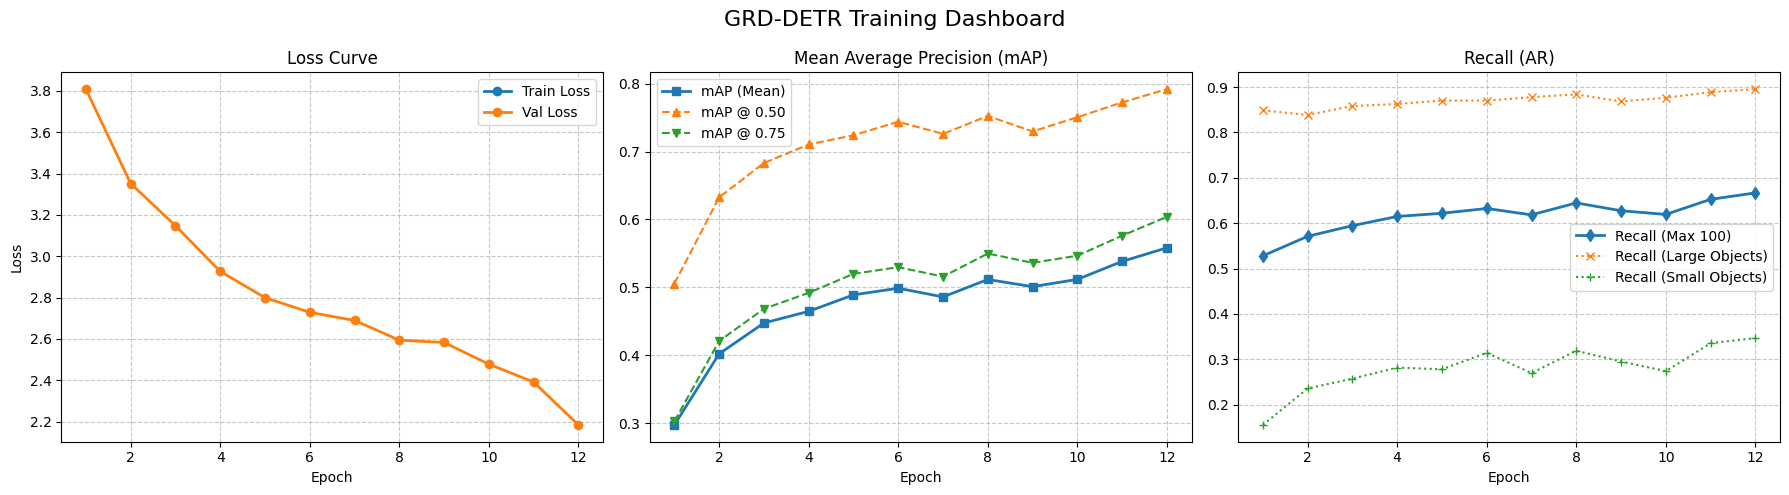


📋 RAW EPOCH METRICS TABLE


,train_loss,val_loss,mAP_mean,mAP_50,mAP_75,mAP_small,mAP_medium,mAP_large,recall_1,recall_10,recall_100,recall_small,recall_medium,recall_large
epoch,,,,,,,,,,,,,,
1,N/A,3.8081,0.2974,0.5054,0.3027,0.0816,0.3106,0.5398,0.1650,0.3942,0.5279,0.1552,0.5868,0.8486
2,N/A,3.3513,0.4021,0.6325,0.4209,0.1305,0.4279,0.6476,0.1871,0.4505,0.5710,0.2356,0.6393,0.8386
3,N/A,3.1477,0.4475,0.6831,0.4684,0.1558,0.4820,0.6954,0.1942,0.4853,0.5945,0.2573,0.6670,0.8582
4,N/A,2.9264,0.4647,0.7104,0.4919,0.1714,0.5083,0.7030,0.1950,0.5006,0.6148,0.2816,0.6958,0.8627
5,N/A,2.7996,0.4889,0.7240,0.5199,0.1767,0.5391,0.7340,0.2018,0.5235,0.6218,0.2779,0.7109,0.8701
6,N/A,2.7286,0.4987,0.7438,0.5297,0.1996,0.5445,0.7356,0.2017,0.5310,0.6324,0.3142,0.7090,0.8702
7,N/A,2.6894,0.4859,0.7260,0.5159,0.1791,0.5339,0.7360,0.2004,0.5269,0.6183,0.2694,0.7032,0.8777
8,N/A,2.5940,0.5116,0.7523,0.5498,0.2104,0.5637,0.7476,0.2028,0.5493,0.6446,0.3187,0.7262,0.8838
9,N/A,2.5828,0.5010,0.7295,0.5361,0.1799,0.5573,0.7488,0.2032,0.5378,0.6274,0.2950,0.7130,0.8684


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from IPython.display import display # 🚨 NEW: Imports Colab's rich display engine

# 1. Load the data
log_path = "/content/drive/MyDrive/GRD_DETR_Saves/recovered_metrics.jsonl"

if not os.path.exists(log_path):
    print("No metrics found yet. Finish an epoch first!")
else:
    data = []
    with open(log_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))

    df = pd.DataFrame(data)

    # 2. Setup the Plotting Canvas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('GRD-DETR Training Dashboard', fontsize=16)

    # --- PLOT 1: LOSS CURVE (Overfitting Detector) ---
    axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='o', linewidth=2)
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 2: mAP METRICS ---
    axes[1].plot(df['epoch'], df['mAP_mean'], label='mAP (Mean)', marker='s', linewidth=2)
    axes[1].plot(df['epoch'], df['mAP_50'], label='mAP @ 0.50', marker='^', linestyle='--')
    axes[1].plot(df['epoch'], df['mAP_75'], label='mAP @ 0.75', marker='v', linestyle='--')
    axes[1].set_title('Mean Average Precision (mAP)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 3: RECALL METRICS ---
    axes[2].plot(df['epoch'], df['recall_100'], label='Recall (Max 100)', marker='d', linewidth=2)
    axes[2].plot(df['epoch'], df['recall_large'], label='Recall (Large Objects)', marker='x', linestyle=':')
    axes[2].plot(df['epoch'], df['recall_small'], label='Recall (Small Objects)', marker='+', linestyle=':')
    axes[2].set_title('Recall (AR)')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 🧮 NEW: INTERACTIVE TABULAR DISPLAY
    # ==========================================================
    print("\n" + "="*50)
    print("📋 RAW EPOCH METRICS TABLE")
    print("="*50)

    # Clean up the table for professional viewing
    display_df = df.copy()
    display_df.set_index('epoch', inplace=True) # Makes the Epoch number the bold row header
    display_df = display_df.round(4)            # Rounds all those crazy floats to 4 decimal places

    # Fill any missing values (like the missing train_loss from recovery) with a clean string
    display_df.fillna("N/A", inplace=True)

    # Render the interactive HTML table
    display(display_df)

## Show Vertically (And Without Training Loss)

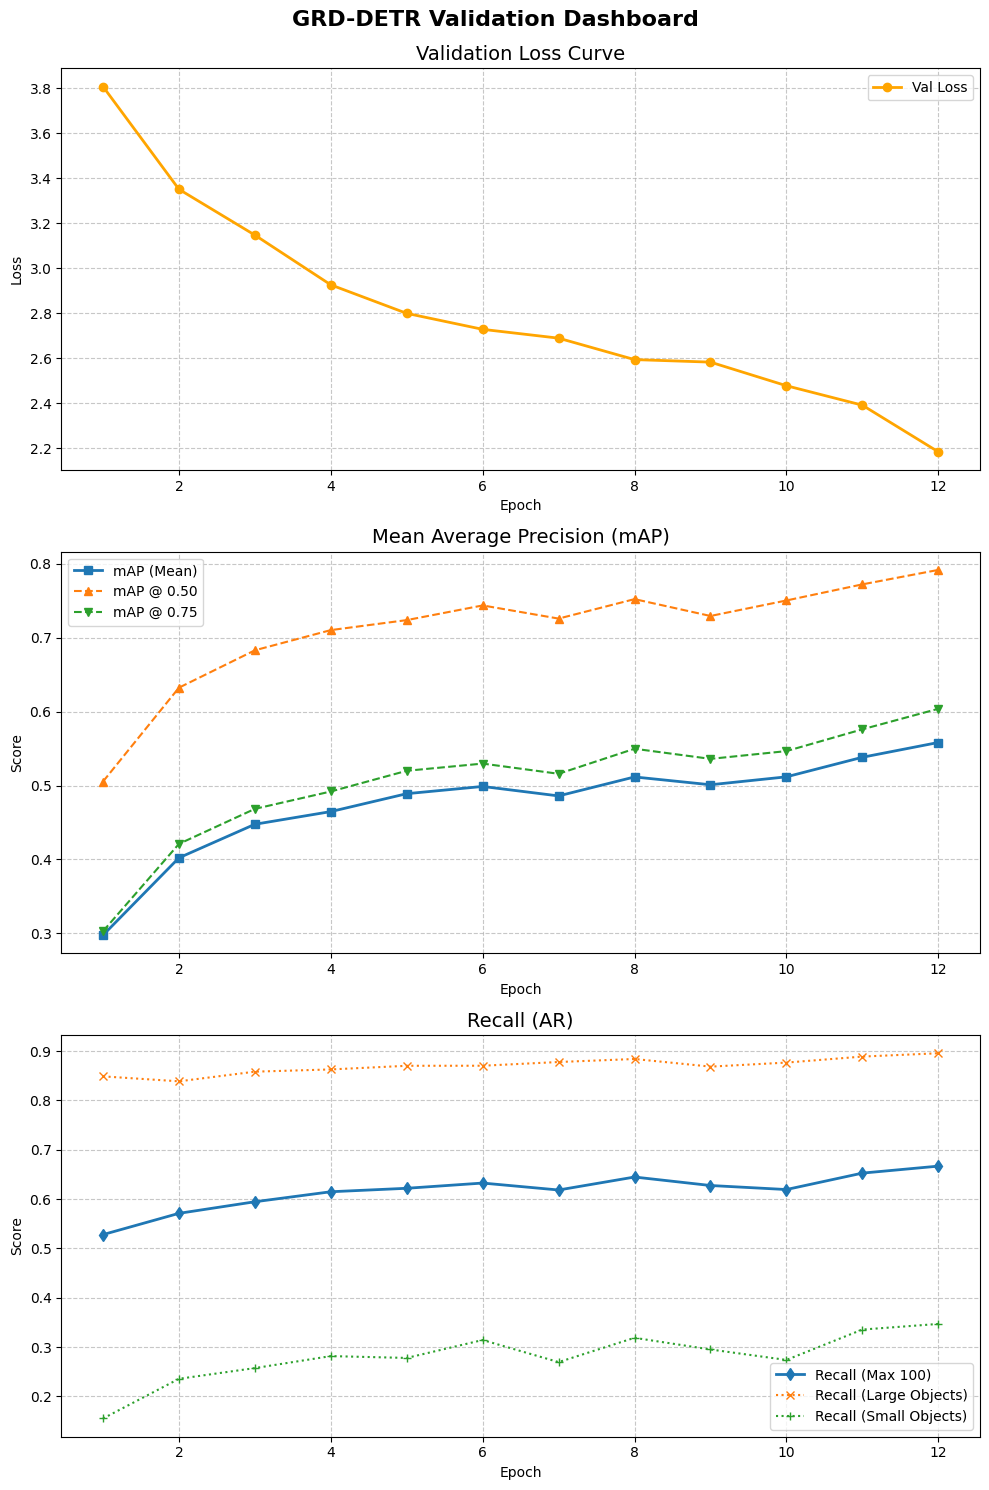


📋 RAW EPOCH METRICS TABLE


,val_loss,mAP_mean,mAP_50,mAP_75,mAP_small,mAP_medium,mAP_large,recall_1,recall_10,recall_100,recall_small,recall_medium,recall_large
epoch,,,,,,,,,,,,,
1,3.8081,0.2974,0.5054,0.3027,0.0816,0.3106,0.5398,0.1650,0.3942,0.5279,0.1552,0.5868,0.8486
2,3.3513,0.4021,0.6325,0.4209,0.1305,0.4279,0.6476,0.1871,0.4505,0.5710,0.2356,0.6393,0.8386
3,3.1477,0.4475,0.6831,0.4684,0.1558,0.4820,0.6954,0.1942,0.4853,0.5945,0.2573,0.6670,0.8582
4,2.9264,0.4647,0.7104,0.4919,0.1714,0.5083,0.7030,0.1950,0.5006,0.6148,0.2816,0.6958,0.8627
5,2.7996,0.4889,0.7240,0.5199,0.1767,0.5391,0.7340,0.2018,0.5235,0.6218,0.2779,0.7109,0.8701
6,2.7286,0.4987,0.7438,0.5297,0.1996,0.5445,0.7356,0.2017,0.5310,0.6324,0.3142,0.7090,0.8702
7,2.6894,0.4859,0.7260,0.5159,0.1791,0.5339,0.7360,0.2004,0.5269,0.6183,0.2694,0.7032,0.8777
8,2.5940,0.5116,0.7523,0.5498,0.2104,0.5637,0.7476,0.2028,0.5493,0.6446,0.3187,0.7262,0.8838
9,2.5828,0.5010,0.7295,0.5361,0.1799,0.5573,0.7488,0.2032,0.5378,0.6274,0.2950,0.7130,0.8684


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from IPython.display import display

# 1. Load the data
log_path = "/content/drive/MyDrive/GRD_DETR_Saves/recovered_metrics.jsonl"

if not os.path.exists(log_path):
    print("No metrics found yet. Finish an epoch first!")
else:
    data = []
    with open(log_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))

    df = pd.DataFrame(data)

    # 2. Setup the Plotting Canvas (3 Rows, 1 Column for vertical stacking)
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle('GRD-DETR Validation Dashboard', fontsize=16, fontweight='bold', y=0.99)

    # --- PLOT 1: LOSS CURVE (Val Loss Only) ---
    axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='o', linewidth=2, color='orange')
    axes[0].set_title('Validation Loss Curve', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 2: mAP METRICS ---
    axes[1].plot(df['epoch'], df['mAP_mean'], label='mAP (Mean)', marker='s', linewidth=2)
    axes[1].plot(df['epoch'], df['mAP_50'], label='mAP @ 0.50', marker='^', linestyle='--')
    axes[1].plot(df['epoch'], df['mAP_75'], label='mAP @ 0.75', marker='v', linestyle='--')
    axes[1].set_title('Mean Average Precision (mAP)', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 3: RECALL METRICS ---
    axes[2].plot(df['epoch'], df['recall_100'], label='Recall (Max 100)', marker='d', linewidth=2)
    axes[2].plot(df['epoch'], df['recall_large'], label='Recall (Large Objects)', marker='x', linestyle=':')
    axes[2].plot(df['epoch'], df['recall_small'], label='Recall (Small Objects)', marker='+', linestyle=':')
    axes[2].set_title('Recall (AR)', fontsize=14)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Score')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    # Automatically adjust spacing between the vertically stacked graphs
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 🧮 INTERACTIVE TABULAR DISPLAY
    # ==========================================================
    print("\n" + "="*50)
    print("📋 RAW EPOCH METRICS TABLE")
    print("="*50)

    # Clean up the table for professional viewing
    display_df = df.copy()

    # Drop the train_loss column completely since we don't have it
    if 'train_loss' in display_df.columns:
        display_df.drop(columns=['train_loss'], inplace=True)

    display_df.set_index('epoch', inplace=True) # Makes the Epoch number the bold row header
    display_df = display_df.round(4)            # Rounds all those crazy floats to 4 decimal places

    # Fill any remaining missing values with a clean string
    display_df.fillna("N/A", inplace=True)

    # Render the interactive HTML table
    display(display_df)

# **EVALUATE GFLOPs**

In [ ]:
!pip install fvcore

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/MultiScaleDeformableAttention-1.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=6611b6335502ee4931749c051c1d6922fb31a420fbdaa0c99cdb65be0fcfab1a
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=c2d2003683548c45aafb8c347684e55c39ed304670630fc3e55282a1af9479f9
  Stored in director

In [ ]:
import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table
from util.misc import NestedTensor

# 1. Put model in absolute inference mode
model.eval()

# 2. 🚨 THE FIX: A proper PyTorch Module Wrapper
class FlopWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, tensor, mask):
        samples = NestedTensor(tensor, mask)
        return self.base_model(samples)

wrapped_for_flops = FlopWrapper(model)
resolutions = [(400, 400), (800, 800)]
results = {}

# 3. The Scaling Loop
for h, w in resolutions:
    print(f"\n🔍 Tracing GRD-DETR at {h}x{w}... (This might take a minute)")

    dummy_tensor = torch.randn(1, 3, h, w).to(accelerator.device)
    dummy_mask = torch.zeros(1, h, w, dtype=torch.bool).to(accelerator.device)

    with torch.no_grad():
        # .unsupported_ops_warnings(False) keeps the console clean
        flops = FlopCountAnalysis(wrapped_for_flops, (dummy_tensor, dummy_mask)).unsupported_ops_warnings(False)

    total_gflops = flops.total() / 1e9
    results[f"{h}x{w}"] = total_gflops

    # Print the massive table ONLY for the 800x800 to avoid console spam
    if h == 800:
        print("\n" + "="*60)
        print(f"Detailed Breakdown for {h}x{w}:")
        print(flop_count_table(flops, max_depth=4))
        print("="*60)

# 4. The Final Comparison
print("\n🔥 GFLOPs SCALING SUMMARY 🔥")
for res, gflops in results.items():
    print(f"🚀 {res}: {gflops:.2f} GFLOPs")

ratio = results['800x800'] / results['400x400']
print(f"\n📈 Scaling Factor: When input dimensions double (4x the pixels), compute increases by {ratio:.2f}x")


🔍 Tracing GRD-DETR at 400x400... (This might take a minute)


base_model.backbone.0.body.1.0.stochastic_depth, base_model.backbone.0.body.1.1.stochastic_depth, base_model.backbone.0.body.1.2.stochastic_depth, base_model.backbone.0.body.3.0.stochastic_depth, base_model.backbone.0.body.3.1.stochastic_depth, base_model.backbone.0.body.3.2.stochastic_depth, base_model.backbone.0.body.5.0.stochastic_depth, base_model.backbone.0.body.5.1.stochastic_depth, base_model.backbone.0.body.5.2.stochastic_depth, base_model.backbone.0.body.5.3.stochastic_depth, base_model.backbone.0.body.5.4.stochastic_depth, base_model.backbone.0.body.5.5.stochastic_depth, base_model.backbone.0.body.5.6.stochastic_depth, base_model.backbone.0.body.5.7.stochastic_depth, base_model.backbone.0.body.5.8.stochastic_depth, base_model.backbone.0.body.7.0.stochastic_depth, base_model.backbone.0.body.7.1.stochastic_depth, base_model.backbone.0.body.7.2.stochastic_depth, base_model.backbone.1, base_model.gat_adapters.0.dropblock, base_model.gat_adapters.1.dropblock, base_model.gat_adapte


🔍 Tracing GRD-DETR at 800x800... (This might take a minute)


base_model.backbone.0.body.1.0.stochastic_depth, base_model.backbone.0.body.1.1.stochastic_depth, base_model.backbone.0.body.1.2.stochastic_depth, base_model.backbone.0.body.3.0.stochastic_depth, base_model.backbone.0.body.3.1.stochastic_depth, base_model.backbone.0.body.3.2.stochastic_depth, base_model.backbone.0.body.5.0.stochastic_depth, base_model.backbone.0.body.5.1.stochastic_depth, base_model.backbone.0.body.5.2.stochastic_depth, base_model.backbone.0.body.5.3.stochastic_depth, base_model.backbone.0.body.5.4.stochastic_depth, base_model.backbone.0.body.5.5.stochastic_depth, base_model.backbone.0.body.5.6.stochastic_depth, base_model.backbone.0.body.5.7.stochastic_depth, base_model.backbone.0.body.5.8.stochastic_depth, base_model.backbone.0.body.7.0.stochastic_depth, base_model.backbone.0.body.7.1.stochastic_depth, base_model.backbone.0.body.7.2.stochastic_depth, base_model.backbone.1, base_model.gat_adapters.0.dropblock, base_model.gat_adapters.1.dropblock, base_model.gat_adapte


Detailed Breakdown for 800x800:
| module                                          | #parameters or shape   | #flops      |
|:------------------------------------------------|:-----------------------|:------------|
| base_model                                      | 51.802M                | 0.171T      |
|  transformer                                    |  17.339M               |  0.109T     |
|   transformer.level_embed                       |   (4, 256)             |             |
|   transformer.encoder                           |   7.694M               |   0.102T    |
|    transformer.encoder.layers                   |    7.693M              |    0.102T   |
|     transformer.encoder.layers.0                |     1.282M             |     17.023G |
|     transformer.encoder.layers.1                |     1.282M             |     17.023G |
|     transformer.encoder.layers.2                |     1.282M             |     17.023G |
|     transformer.encoder.layers.3                |     1

# **MOUNT THAT GOOGLE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **CLEAN IT LAH, SO DIRTY**

In [ ]:
import gc
import torch
import ctypes
import sys

def deep_clean_colab_memory():
    print("🧹 Initiating Deep Memory Clean...")

    # 1. Clear Jupyter Tracebacks
    # Jupyter holds onto the memory of crashed variables so you can debug them.
    # This deletes that hidden history.
    sys.last_traceback = None
    sys.last_type = None
    sys.last_value = None

    # 2. Python Garbage Collection (System RAM)
    # Forces Python to delete any unreferenced objects.
    collected = gc.collect()
    print(f"   Python GC collected {collected} objects.")

    # 3. PyTorch GPU Cache (VRAM)
    # PyTorch holds onto VRAM even after deleting variables to speed up future allocations.
    # This forces it to give the VRAM back to the GPU.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect() # Cleans up multiprocessing memory locks
        current_vram = torch.cuda.memory_allocated() / (1024 ** 2)
        print(f"   GPU VRAM Cleared. Currently holding: {current_vram:.2f} MB")
    else:
        print("   No GPU detected to clear.")

    # 4. Linux C-Level Memory Trim (The Secret Colab Weapon)
    # Sometimes Python deletes variables, but the underlying Linux OS refuses to give
    # the RAM back to Colab. This forces the OS to release it.
    try:
        libc = ctypes.CDLL("libc.so.6")
        libc.malloc_trim(0)
        print("   Linux OS memory successfully trimmed.")
    except Exception as e:
        print(f"   Could not trim OS memory: {e}")

    print("✨ Colab Memory is clean and ready to train!")

# Run the cleaner
deep_clean_colab_memory()

🧹 Initiating Deep Memory Clean...
   Python GC collected 423 objects.
   GPU VRAM Cleared. Currently holding: 543.58 MB
   Linux OS memory successfully trimmed.
✨ Colab Memory is clean and ready to train!


# **TEST THE VALIDATION LOSS**

In [ ]:
def test_validation_loss():
    print("\\n🧪 Running Validation Loss Diagnostic...")

    # 1. Setup a dummy configuration
    model_args = SimpleNamespace(
        hidden_dim=256, dropout=0.1, nheads=8, num_queries=150, # <-- 150 Queries
        dim_feedforward=2048, enc_layers=6, unic_layers=0, dec_layers=6,
        pre_norm=True, query_dim=4, transformer_activation='gelu',
        num_patterns=0, num_feature_levels=4, enc_n_points=4, dec_n_points=4,
        use_deformable_box_attn=False, box_attn_type='roi_align',
        decoder_layer_noise=False, add_channel_attention=False,
        add_pos_value=False, random_refpoints_xy=False, two_stage_type='no',
        two_stage_pat_embed=0, two_stage_add_query_num=0, two_stage_learn_wh=False,
        two_stage_keep_all_tokens=False, dec_layer_number=None,
        decoder_sa_type='sa', decoder_module_seq=['sa', 'ca', 'ffn'],
        embed_init_tgt=True, use_detached_boxes_dec_out=False, amp=True,
        use_dn=True, save_results=False, debug=False, output_dir='./workspace/', useCats=True
    )

    # 2. Recreate the Validation Weight Dictionary
    val_weight_dict = {'loss_ce': 1.0, 'loss_bbox': 5.0, 'loss_giou': 2.0}
    for i in range(model_args.dec_layers - 1):
        val_weight_dict.update({k + f'_{i}': v for k, v in val_weight_dict.items()})

    # 3. Initialize the Matcher and Validation Criterion
    matcher = HungarianMatcher(cost_class=2.0, cost_bbox=5.0, cost_giou=2.0)
    val_criterion = SetCriterion(1, matcher, val_weight_dict, 0.25, ['labels', 'boxes', 'cardinality'])

    # Crucial Fix: Manually override the use_dn flag
    if hasattr(val_criterion, 'use_dn'):
        val_criterion.use_dn = False

    val_criterion.eval()

    # 4. Create Fake Model Outputs (Simulating a forward pass during validation)
    # 2 images, 150 queries
    # 4. Create Fake Model Outputs
    outputs = {
        'pred_logits': torch.randn(2, 150, 1), # Changed to 1 class for accuracy
        'pred_boxes': torch.rand(2, 150, 4),

        # --- ADD THIS STUB TO BYPASS THE KEYERROR ---
        'dn_meta': {
            'dn_positive_idx': torch.tensor([]),
            'dn_num_group': 0,
            'cap_dn_conf_dot': None
        }
    }

    # 5. Create Fake Targets (Simulating Ground Truth)
    targets = [
        {
            'labels': torch.tensor([0]),
            'boxes': torch.rand(1, 4),
            'visibility_weights': torch.tensor([1.0])
        },
        {
            'labels': torch.tensor([0, 0]),
            'boxes': torch.rand(2, 4),
            'visibility_weights': torch.tensor([0.5, 0.8])
        }
    ]

    try:
        # Attempt to calculate the loss
        loss_dict = val_criterion(outputs, targets)
        print(f"   Calculated Losses: {list(loss_dict.keys())[:3]}...") # Print first few keys
        print("✅ SUCCESS: Validation Criterion correctly calculated loss without crashing.")
    except Exception as e:
        print(f"❌ FAILED: Exception occurred during validation loss calculation: {e}")

test_validation_loss()

\n🧪 Running Validation Loss Diagnostic...
🚀 CONFIRMED: VE-DINO Visibility Loss is actively calculating weights!
   Calculated Losses: ['loss_bbox_dn', 'loss_giou_dn', 'loss_ce_dn']...
✅ SUCCESS: Validation Criterion correctly calculated loss without crashing.


# **Possible UI**

In [ ]:
import gradio as gr
import torch
from PIL import Image, ImageDraw
import torchvision.transforms.functional as F

# NOTE: Ensure your `model`, `device`, and `postprocessors` are already loaded in memory before running this!

def detect_people(input_image):
    if input_image is None:
        return None

    # 1. Preprocess the image for the Transformer
    # Convert PIL Image to tensor and apply standard ImageNet normalization
    img_tensor = F.to_tensor(input_image)
    img_tensor = F.normalize(img_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Add the batch dimension (so shape becomes [1, C, H, W])
    samples = img_tensor.unsqueeze(0).to(device)

    # 2. Extract original size for DINO's precise bounding box scaling
    orig_size = torch.as_tensor([[input_image.height, input_image.width]]).to(device)

    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        outputs = model(samples)
        # Use your exact PostProcess setup to get absolute coordinates
        results = postprocessors['bbox'](outputs, orig_size)[0]

    # 4. Filter and Draw
    # We use PIL's ImageDraw to directly paint boxes onto the original image
    draw = ImageDraw.Draw(input_image)
    boxes = results['boxes'].cpu().numpy()
    scores = results['scores'].cpu().numpy()

    # 🚨 CONFIDENCE THRESHOLD: We don't want 300 boxes on the screen!
    CONFIDENCE_THRESHOLD = 0.45

    for box, score in zip(boxes, scores):
        if score > CONFIDENCE_THRESHOLD:
            # DINO outputs absolute coordinates: [x_min, y_min, x_max, y_max]
            x_min, y_min, x_max, y_max = box

            # Draw the bounding box (Red, 3 pixels thick)
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=3)

            # Draw the confidence score above the box
            draw.text((x_min, y_min - 15), f"Person: {score:.2f}", fill="red")

    return input_image

# ==========================================================
# 5. LAUNCH THE WEB UI
# ==========================================================
print("🚀 Launching Web Interface...")

interface = gr.Interface(
    fn=detect_people,
    inputs=gr.Image(type="pil", sources=["upload", "webcam"]), # Activates both File Upload and WebCam!
    outputs=gr.Image(type="pil"),
    title="GRD-DETR Disaster Occlusion Detector",
    description="Upload an image or take a picture with your webcam to detect people in debris using our custom architecture.",
    allow_flagging="never"
)

# share=True generates a temporary public link you can open on your phone!
interface.launch(share=True, debug=True)